# 7. Modelio palyginimas (tas pats skaidymas, tos pačios metrikos)

Čia neskaičiuojami nauji hiperparametrai. Skaitomi `results/comparison.csv` ir
`results/metrics.json`, kuriuos sukuria

```
python -m winequality.run_experiment
```

Jei failų nėra, paleiskite šią komandą projekto šaknyje (trunka ~1–2 min).


In [9]:
%matplotlib inline
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
root = here if (here / "winequality").exists() else here.parent
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "notebooks"))

from winequality.config import RESULTS, FIGURES, SPLIT_SEED, DEFAULT_SEED

csv_path = RESULTS / "comparison.csv"
json_path = RESULTS / "metrics.json"
assert csv_path.exists(), "Nėra results/comparison.csv — paleiskite python -m winequality.run_experiment"
cmp = pd.read_csv(csv_path)
rep = json.loads(json_path.read_text(encoding="utf-8"))
print("split_seed =", rep["split_seed"], "  model_seed =", rep["model_seed"])
display(cmp.round(4))


split_seed = 0   model_seed = 0


,wine,model,mae,mae_rounded,acc_0.5,acc_1.0,kappa_w,macro_f1
0,red,mean,0.6837,0.6562,0.4000,0.8250,0.0000,0.3014
1,red,linear,0.4908,0.4125,0.6219,0.8750,0.5412,0.5077
2,red,svr,0.4734,0.4125,0.6094,0.9000,0.5811,0.4698
3,red,mlp,0.4721,0.3688,0.6500,0.8812,0.6182,0.5355
4,red,rbf,0.4973,0.3969,0.6281,0.8750,0.5890,0.5468
5,red,rf,0.4845,0.4125,0.6031,0.8906,0.5952,0.5484
6,white,mean,0.6734,0.6333,0.4484,0.7457,0.0000,0.2848
7,white,linear,0.5733,0.5332,0.5199,0.8631,0.4448,0.4565
8,white,svr,0.5336,0.4944,0.5444,0.8570,0.5425,0.5161
9,white,mlp,0.5723,0.5373,0.5189,0.8417,0.4742,0.4947


## MAE stulpelinė diagrama pagal vyno tipą


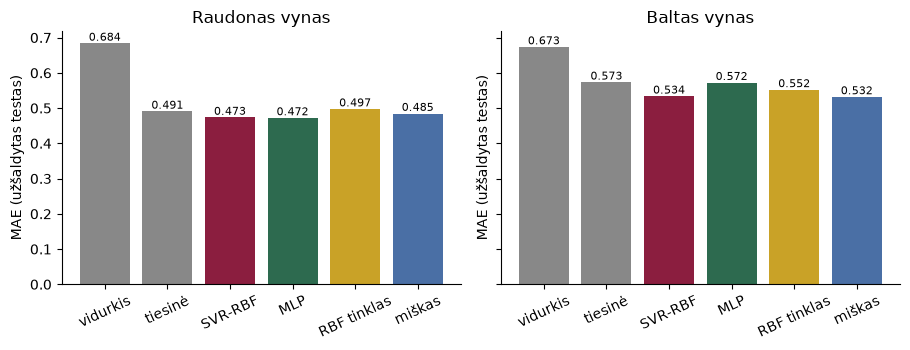

In [10]:
tvarka = ["mean", "linear", "svr", "mlp", "rbf", "rf"]
spalvos = {
    "mean": "#888888", "linear": "#888888", "svr": "#8b1e3f",
    "mlp": "#2d6a4f", "rbf": "#c9a227", "rf": "#4a6fa5",
}
etiketes = {
    "mean": "vidurkis", "linear": "tiesinė", "svr": "SVR-RBF",
    "mlp": "MLP", "rbf": "RBF tinklas", "rf": "miškas",
}

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.6), sharey=True)
for ax, wine, tit in zip(axes, ["red", "white"], ["Raudonas vynas", "Baltas vynas"]):
    d = cmp[cmp["wine"] == wine].set_index("model").loc[tvarka]
    ax.bar([etiketes[m] for m in tvarka], d["mae"], color=[spalvos[m] for m in tvarka])
    for i, v in enumerate(d["mae"]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(tit)
    ax.set_ylabel("MAE (užšaldytas testas)")
    ax.tick_params(axis="x", rotation=25)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


## Hipotezės H1 / H2 ir abliacija A1


In [11]:
eilutes = []
for wine, block in rep["wines"].items():
    h1, h2 = block["h1"], block["h2"]
    a1 = block["ablation_a1_kernel"]
    leak = block["robustness_leakage"]
    noise = block["robustness_noise"]
    eilutes.append({
        "vynas": wine,
        "H1 ΔMAE vs tiesinė": h1["relative_improvement"],
        "H1 galioja (≥5 %)": h1["h1_holds"],
        "H2 SVR−RF": h2["mae_svr_minus_mae_rf"],
        "H2 ≤0.02": h2["non_inferiority_holds"],
        "A1 linear MAE": a1["linear"]["metrics"]["mae"],
        "A1 RBF MAE": a1["rbf"]["metrics"]["mae"],
        "nutekėjimo grupės (random)": leak["random"]["overlapping_groups"],
        "MAE random split": leak["random"]["metrics"]["mae"],
        "MAE grupinis": leak["group_aware"]["metrics"]["mae"],
        "ΔMAE nuo 0.1σ triukšmo": noise["mae_delta"],
    })
santrauka = pd.DataFrame(eilutes).set_index("vynas")
display(santrauka.round(4))


,H1 ΔMAE vs tiesinė,H1 galioja (≥5 %),H2 SVR−RF,H2 ≤0.02,A1 linear MAE,A1 RBF MAE,nutekėjimo grupės (random),MAE random split,MAE grupinis,ΔMAE nuo 0.1σ triukšmo
vynas,,,,,,,,,,
red,0.0354,False,-0.0111,True,0.4883,0.4734,74,0.4292,0.4734,0.0122
white,0.0692,True,0.0019,True,0.5707,0.5336,274,0.5072,0.5336,0.0017


## Automatiniu būdu suformuluota išvada


In [12]:
def laimetojas(wine: str) -> str:
    d = cmp[cmp["wine"] == wine].nsmallest(1, "mae").iloc[0]
    return f"{d['model']} (MAE={d['mae']:.3f})"

print("Mažiausias MAE raudonam:", laimetojas("red"))
print("Mažiausias MAE baltam:", laimetojas("white"))
print()
print(
    "Plane pagrindinis metodas vis tiek SVR-RBF, nes H2 neleidžia keisti į RF, "
    "kol RF nepranoksta daugiau nei 0,02 MAE. MLP raudonam beveik lygus SVR, "
    "baltam — beveik tiesinei regresijai. RBF tinklas (fiksuoti centrai) baltam "
    "yra tarp tiesinės ir SVR, kaip ir buvo hipotezuota."
)

# jautrumas (alkoholis turi kilti, lakiosios rūgštys — kristi)
for wine, block in rep["wines"].items():
    s = block["sensitivity"]
    print(f"\nJautrumas ({wine}): alkoholis Δf={s['alcohol']['delta_f']:+.3f}, "
          f"lakiosios rūgštys Δf={s['volatile acidity']['delta_f']:+.3f}")


Mažiausias MAE raudonam: mlp (MAE=0.472)
Mažiausias MAE baltam: rf (MAE=0.532)

Plane pagrindinis metodas vis tiek SVR-RBF, nes H2 neleidžia keisti į RF, kol RF nepranoksta daugiau nei 0,02 MAE. MLP raudonam beveik lygus SVR, baltam — beveik tiesinei regresijai. RBF tinklas (fiksuoti centrai) baltam yra tarp tiesinės ir SVR, kaip ir buvo hipotezuota.

Jautrumas (red): alkoholis Δf=+0.797, lakiosios rūgštys Δf=-0.443

Jautrumas (white): alkoholis Δf=+0.412, lakiosios rūgštys Δf=-0.336


## Kaip skaityti rezultatą egzaminui

1. **Visos eilutės** skaičiuotos su `SPLIT_SEED = 0` ir tais pačiais 11 požymių.
2. Hiperparametrai parinkti **tik 80 % mokymo** (`GroupKFold`), testas liestas vieną kartą.
3. Neigiamas H1 raudonam vynui yra priimtinas: eksperimentas korektiškas, 5 % slenkstis per griežtas.
4. Atsitiktinis skaidymas **pagerina** SVR MAE dėl 74 / 274 nutekėjusių dublikatų grupių — todėl grupinis skaidymas privalomas.
